In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('classification_data.csv')

In [ ]:
df.head()

,Age,6th_Stage,Differentiated,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Reginol_Node_Positive,Mortality_Status
0,68.0,1,2,0,4.0,1,1,24.0,1,1
1,50.0,3,1,0,35.0,1,1,14.0,5,1
2,58.0,5,1,0,63.0,1,1,14.0,7,1
3,58.0,1,2,0,18.0,1,1,2.0,1,1
4,47.0,2,2,0,41.0,1,1,3.0,1,1


Train-Test split

In [ ]:
X = df.drop(columns=['Mortality_Status'])
y = df['Mortality_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set class distribution:\n", y_train.value_counts(normalize=True))
print("Test set class distribution:\n", y_test.value_counts(normalize=True))

Train set class distribution:
 Mortality_Status
1    0.84649
0    0.15351
Name: proportion, dtype: float64
Test set class distribution:
 Mortality_Status
1    0.846633
0    0.153367
Name: proportion, dtype: float64


Features

In [ ]:
for col in X.columns:
    print(col)

Age
6th_Stage
Differentiated
A_Stage
Tumor_Size
Estrogen_Status
Progesterone_Status
Regional_Node_Examined
Reginol_Node_Positive


In [ ]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X shape: (4007, 9)
X_train shape: (3205, 9)
X_test shape: (802, 9)


NAIVE BAYESIAN MODEL

In [ ]:
nb_model = GaussianNB()


In [ ]:
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC

In [ ]:
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]  # Probability estimates for class 1

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

Accuracy:  0.8130
Precision: 0.8861
Recall:    0.8940
F1 Score:  0.8900
AUC-ROC:   0.7487


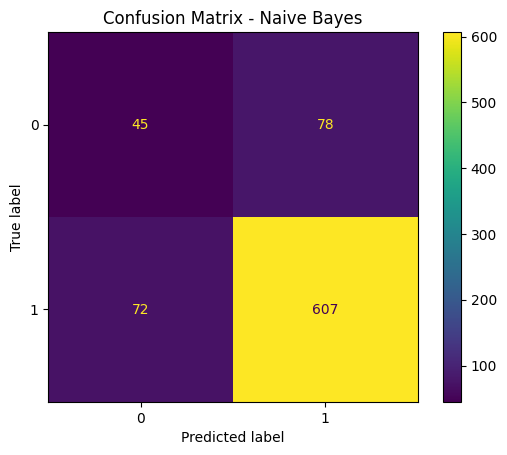

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(nb_model, X_test, y_test)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


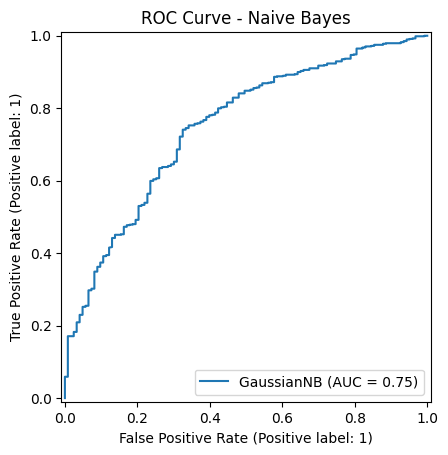

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(nb_model, X_test, y_test)
plt.title("ROC Curve - Naive Bayes")
plt.show()


Logistic Regression

In [ ]:
log_model = LogisticRegression(solver='liblinear', random_state=42)

In [ ]:
log_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

Accuracy:  0.8603
Precision: 0.8677
Recall:    0.9853
F1 Score:  0.9228
AUC-ROC:   0.7818


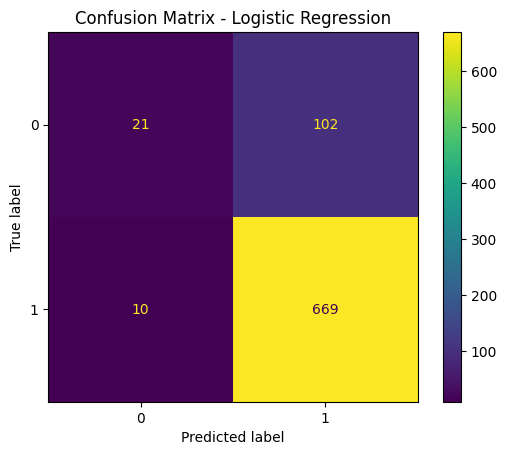

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


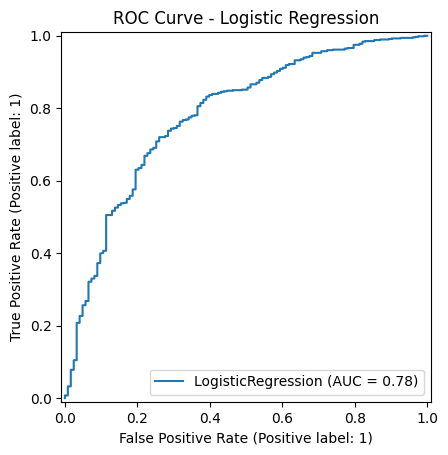

In [ ]:
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()


In [ ]:
# Define the base model
lr = LogisticRegression(max_iter=1000)

# Define the hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' supports both 'l1' and 'l2'
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Best model
best_lr = grid_search.best_estimator_

# Evaluate best model
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))


Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8591022443890274
Precision: 0.8656330749354005
Recall: 0.9867452135493373
F1 Score: 0.9222298692360633
AUC-ROC: 0.7849240274435145


In [ ]:
# Confusion matrix before tuning

confusion_matrix(y_test, y_pred)


array([[ 19, 104],
       [  9, 670]])

In [ ]:

# Confusion matrix after tuning
y_pred_after = best_lr.predict(X_test)
confusion_matrix(y_test, y_pred_after)


array([[ 19, 104],
       [  9, 670]])

K Nearest Neighbor

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Selecting best K value

In [ ]:
k_values = list(range(1, 100, 2))
auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    auc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
    auc_scores.append(auc)
    print(f'K={k}: Cross-validated AUC = {auc:.4f}')

best_k = k_values[np.argmax(auc_scores)]
print(f'\nBest K found: {best_k} with AUC = {max(auc_scores):.4f}')

K=1: Cross-validated AUC = 0.5480
K=3: Cross-validated AUC = 0.6052
K=5: Cross-validated AUC = 0.6323
K=7: Cross-validated AUC = 0.6388
K=9: Cross-validated AUC = 0.6583
K=11: Cross-validated AUC = 0.6716
K=13: Cross-validated AUC = 0.6819
K=15: Cross-validated AUC = 0.6879
K=17: Cross-validated AUC = 0.6866
K=19: Cross-validated AUC = 0.6929
K=21: Cross-validated AUC = 0.6957
K=23: Cross-validated AUC = 0.6948
K=25: Cross-validated AUC = 0.6991
K=27: Cross-validated AUC = 0.7003
K=29: Cross-validated AUC = 0.6991
K=31: Cross-validated AUC = 0.6965
K=33: Cross-validated AUC = 0.7008
K=35: Cross-validated AUC = 0.7001
K=37: Cross-validated AUC = 0.6992
K=39: Cross-validated AUC = 0.7018
K=41: Cross-validated AUC = 0.6997
K=43: Cross-validated AUC = 0.6989
K=45: Cross-validated AUC = 0.6991
K=47: Cross-validated AUC = 0.7003
K=49: Cross-validated AUC = 0.7002
K=51: Cross-validated AUC = 0.7002
K=53: Cross-validated AUC = 0.7019
K=55: Cross-validated AUC = 0.7021
K=57: Cross-validated AUC

In [ ]:
knn = KNeighborsClassifier(n_neighbors=87)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
fscore = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1 Score: {fscore:.4f}')
print(f'AUC ROC: {auc_roc:.4f}')

Accuracy: 0.8529
Recall: 1.0000
Precision: 0.8519
F1 Score: 0.9201
AUC ROC: 0.7635


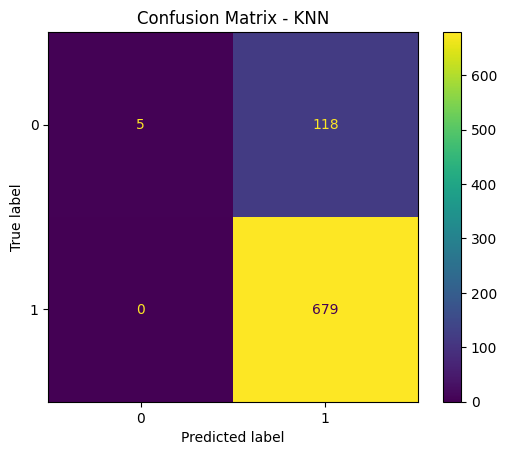

In [ ]:
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("Confusion Matrix - KNN")
plt.show()


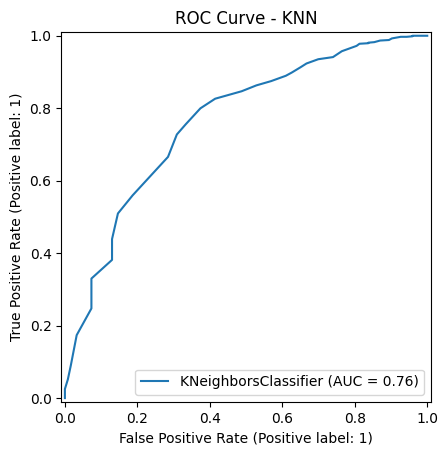

In [ ]:
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("ROC Curve - KNN")
plt.show()


Hyper parameter tuning in Logistic Regression

In [ ]:
param_grid = [
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs', 'saga']
    }
]
logreg = LogisticRegression(max_iter=100, random_state=42)

grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, error_score='raise')

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Cross-Validation Accuracy:", best_score)

results_df = pd.DataFrame(grid_search.cv_results_)
print("\nHyperparameter tuning results:\n")
print(results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])


Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8533541341653667

Hyperparameter tuning results:

                                               params  mean_test_score  \
0   {'C': 0.01, 'penalty': 'l1', 'solver': 'liblin...         0.846490   
1   {'C': 0.1, 'penalty': 'l1', 'solver': 'libline...         0.850546   
2    {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}         0.852730   
3   {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}         0.853354   
4   {'C': 100, 'penalty': 'l1', 'solver': 'libline...         0.853354   
5   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...         0.849298   
6     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}         0.851482   
7      {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}         0.847738   
8   {'C': 0.1, 'penalty': 'l2', 'solver': 'libline...         0.850858   
9      {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}         0.850546   
10      {'C': 0.1, 'penalty': 

In [ ]:
best_logreg = LogisticRegression(
    penalty=best_params['penalty'],
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=100,
    random_state=42
)

In [ ]:
best_logreg.fit(X_train, y_train)

y_pred = best_logreg.predict(X_test)
y_pred_proba = best_logreg.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"\nValidation Results for Best Model (Logistic Regression):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC ROC: {auc_roc:.4f}")


Validation Results for Best Model (Logistic Regression):
Accuracy: 0.8591
Precision: 0.8656
Recall: 0.9867
F1 Score: 0.9222
AUC ROC: 0.7849


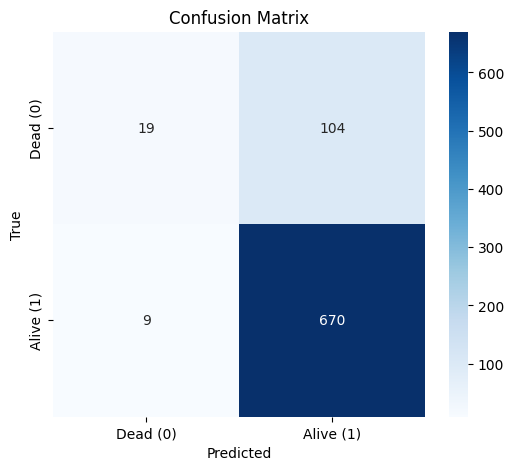

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dead (0)', 'Alive (1)'], yticklabels=['Dead (0)', 'Alive (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()